# Atomization Energies — VDZ(d,s) Basis

This notebook computes and analyzes **atomization energies** for all 200 molecules in the W4-17 dataset at the VDZ(d,s) basis set level.

Four levels of theory are compared:

| Method | Molecule energies | Atom energies |
|---|---|---|
| **AFQMC** | `all_vdzsd.dat` | `atom_uhf_vdzsd.dat` |
| **UHF-CCSD(T)** | `reference_vdzsd.dat` | `atom_ref_vdzsd.dat` |
| **UHF-CCSDT** | `reference_vdzsd.dat` | `atom_ref_vdzsd.dat` |
| **CCSDT(Q)** | `reference_vdzsd.dat` | `atom_ref_vdzsd.dat` |

**Atomization energy:**
$$E_{\rm at} = \sum_i n_i\, E(\text{atom}_i) - E(\text{molecule}) \quad (E_h)$$

All final energies are reported in **kcal/mol** (1 $E_h$ = 627.5094740631 kcal/mol).

**AFQMC stochastic uncertainty propagation:**
$$\sigma(E_{\rm at}) = \sqrt{\sigma_{\rm mol}^2 + \sum_i n_i^2\,\sigma_{\rm atom_i}^2}$$

**Molecule shell type** is determined from the `2S` column in `all_vdzsd.dat`:
- `2S = 0` → closed-shell → geometry from `w4_17_xyz/closed_shell/`
- `2S > 0` → open-shell → geometry from `w4_17_xyz/open_shell/`

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import Counter

HARTREE_TO_KCAL = 627.5094740631

BASE    = '/home/yichi/research/w4_17/w4-17_all'
SUMMARY = os.path.join(BASE, 'summary')
XYZ_CS  = os.path.join(BASE, 'w4_17_xyz', 'closed_shell')
XYZ_OS  = os.path.join(BASE, 'w4_17_xyz', 'open_shell')

def skip_line(line):
    """Return True for blank, comment, separator, or header lines."""
    s = line.strip()
    return not s or s.startswith('#') or s.startswith('-') or s.startswith('Molecule')

## 1. Load Molecular Energies

### 1a. AFQMC results (`all_vdzsd.dat`)

In [2]:
mols = {}   # name -> dict of energies & metadata

with open(os.path.join(SUMMARY, 'all_vdzsd.dat')) as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        mols[p[0]] = {
            'charge':      int(p[1]),
            'twos':        int(p[2]),
            'frozen':      int(p[3]),
            'E_HF':        float(p[4]),
            'E_CCSD':      float(p[5]),
            'E_CCSD_T':    float(p[6]),
            'E_AFQMC':     float(p[7]),
            'E_AFQMC_err': float(p[8]),
        }

print(f"Loaded {len(mols)} molecules from all_vdzsd.dat")
open_shell   = [m for m, d in mols.items() if d['twos'] > 0]
closed_shell = [m for m, d in mols.items() if d['twos'] == 0]
print(f"  Closed-shell: {len(closed_shell)},  Open-shell: {len(open_shell)}")

Loaded 200 molecules from all_vdzsd.dat
  Closed-shell: 160,  Open-shell: 40


### 1b. Coupled-cluster reference energies (`reference_vdzsd.dat`)

Columns: `Molecule | E_HF | E_CCSD | E_UHF-UCCSD(T) | E_UHF-UCCSDT | E_CCSDT(Q)`

In [3]:
ref = {}   # name -> dict

with open(os.path.join(SUMMARY, 'reference_vdzsd.dat')) as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        ref[p[0]] = {
            'E_HF':     float(p[1]),
            'E_CCSD':   float(p[2]),
            'E_CCSD_T': float(p[3]),   # UHF-UCCSD(T)
            'E_CCSDT':  float(p[4]),   # UHF-UCCSDT
            'E_CCSDTQ': float(p[5]),   # CCSDT(Q)
        }

common = set(mols) & set(ref)
print(f"Loaded {len(ref)} molecules from reference_vdzsd.dat")
print(f"Common with AFQMC data: {len(common)}")

Loaded 200 molecules from reference_vdzsd.dat
Common with AFQMC data: 200


## 2. Load Atomic Energies

### 2a. AFQMC atom energies (`atom_uhf_vdzsd.dat`)
Columns: `Molecule | Charge | 2S | frozen | E_HF | E_CCSD | E_CCSD(T) | E_AFQMC | E_AFQMC_ERR`

In [ ]:
atom_afqmc = {}

with open(os.path.join(SUMMARY, 'atom_uhf_vdzsd.dat')) as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        atom_afqmc[p[0].lower()] = {
            'E_AFQMC':     float(p[7]),
            'E_AFQMC_err': float(p[8]),
        }

print("Atoms with AFQMC energies:", sorted(atom_afqmc))
print()
print(f"{'Atom':>6}  {'E_AFQMC (Eh)':>182}  {'σ (Eh)':>12}")
for atom in sorted(atom_afqmc):
    d = atom_afqmc[atom]
    print(f"{atom:>6}  {d['E_AFQMC']:18.5f}  {d['E_AFQMC_err']:12.5f}")

Atoms with AFQMC energies: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']

  Atom        E_AFQMC (Eh)        σ (Eh)
    al          -241.92174       0.00002
     b           -24.58987       0.00002
     c           -37.76071       0.00002
    cl          -459.59915       0.00002
     f           -99.52779       0.00003
     h            -0.49928       0.00000
     n           -54.47868       0.00001
     o           -74.91012       0.00002
     p          -340.79165       0.00001
     s          -397.60085       0.00002
    si          -288.91554       0.00002


### 2b. Coupled-cluster atom energies (`atom_ref_vdzsd.dat`)
Columns: `Molecule | Charge | 2S | frozen | E_HF | E_CCSD | E_UHF-CCSD(T) | E_UHF-CCSDT | E_CCSDT(Q)`

In [6]:
atom_ref = {}

with open(os.path.join(SUMMARY, 'atom_ref_vdzsd.dat')) as f:
    for line in f:
        if skip_line(line):
            continue
        p = line.split()
        atom_ref[p[0].lower()] = {
            'E_CCSD_T':  float(p[6]),   # UHF-CCSD(T)
            'E_CCSDT':   float(p[7]),   # UHF-CCSDT
            'E_CCSDTQ':  float(p[8]),   # CCSDT(Q)
        }

print("Atoms with CC reference energies:", sorted(atom_ref))
print()
print(f"{'Atom':>6}  {'E_CCSD(T)':>14}  {'E_CCSDT':>14}  {'E_CCSDT(Q)':>14}")
for atom in sorted(atom_ref):
    d = atom_ref[atom]
    print(f"{atom:>6}  {d['E_CCSD_T']:14.6f}  {d['E_CCSDT']:14.6f}  {d['E_CCSDTQ']:14.6f}")

Atoms with CC reference energies: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']

  Atom       E_CCSD(T)         E_CCSDT      E_CCSDT(Q)
    al     -241.921269     -241.921629     -241.921629
     b      -24.589408      -24.589772      -24.589772
     c      -37.760377      -37.760688      -37.760710
    cl     -459.598893     -459.599086     -459.599230
     f      -99.527574      -99.527650      -99.527760
     h       -0.499278       -0.499278       -0.499278
     n      -54.478502      -54.478631      -54.478664
     o      -74.909950      -74.910062      -74.910131
     p     -340.791331     -340.791603     -340.791679
     s     -397.600553     -397.600811     -397.600912
    si     -288.915089     -288.915487     -288.915522


## 3. Parse XYZ Geometries → Atomic Compositions

Molecules with `2S = 0` are closed-shell (geometry in `closed_shell/`);  
molecules with `2S > 0` are open-shell (geometry in `open_shell/`).

In [7]:
def parse_xyz(path):
    """Return Counter of element symbols (lowercase) from an XYZ file."""
    with open(path) as f:
        lines = f.readlines()
    n_atoms = int(lines[0].strip())
    comp = Counter()
    for line in lines[2:2 + n_atoms]:
        comp[line.split()[0].lower()] += 1
    return comp


compositions = {}
for mol, d in mols.items():
    xyz_dir = XYZ_OS if d['twos'] > 0 else XYZ_CS
    compositions[mol] = parse_xyz(os.path.join(xyz_dir, f'{mol}.xyz'))

# Sanity check: all atoms must be in the reference tables
all_elem = set(e for comp in compositions.values() for e in comp)
print("Unique elements across dataset:", sorted(all_elem))
missing_afqmc = all_elem - set(atom_afqmc)
missing_ref   = all_elem - set(atom_ref)
print("Elements missing from AFQMC atom table:", missing_afqmc if missing_afqmc else "None")
print("Elements missing from CC atom table:   ", missing_ref   if missing_ref   else "None")

# Example compositions
print()
for mol in ['cn', 'benzene', 'allyl', 'h2', 'sf6']:
    if mol in compositions:
        comp_str = ' '.join(f"{e.capitalize()}{n if n>1 else ''}" for e, n in sorted(compositions[mol].items()))
        print(f"  {mol:20s}: {comp_str}")

Unique elements across dataset: ['al', 'b', 'c', 'cl', 'f', 'h', 'n', 'o', 'p', 's', 'si']
Elements missing from AFQMC atom table: None
Elements missing from CC atom table:    None

  cn                  : C N
  benzene             : C6 H6
  allyl               : C3 H5
  h2                  : H2
  sf6                 : F6 S


## 4. Compute Atomization Energies

$$E_{\rm at}(\text{mol}) = \underbrace{\sum_i n_i\, E(\text{atom}_i)}_{\text{sum of atomic energies}} - E(\text{mol})$$

In [8]:
mol_names  = []
formulas   = []
shells     = []
twos_arr   = []

AE_AFQMC     = []
AE_AFQMC_err = []
AE_CCSD_T    = []
AE_CCSDT     = []
AE_CCSDTQ    = []

for mol in sorted(mols.keys()):
    comp = compositions[mol]
    twos = mols[mol]['twos']

    # Chemical formula string (e.g. "C2H6")
    formula = ''.join(
        f"{e.capitalize()}{n if n > 1 else ''}"
        for e, n in sorted(comp.items())
    )

    # --- AFQMC ---
    E_at_afqmc   = sum(n * atom_afqmc[e]['E_AFQMC']     for e, n in comp.items())
    ae_afqmc     = (E_at_afqmc - mols[mol]['E_AFQMC']) * HARTREE_TO_KCAL

    # propagate stochastic uncertainty
    sigma_atom   = np.sqrt(sum((n * atom_afqmc[e]['E_AFQMC_err'])**2 for e, n in comp.items()))
    sigma_mol    = mols[mol]['E_AFQMC_err']
    ae_afqmc_err = np.sqrt(sigma_mol**2 + sigma_atom**2) * HARTREE_TO_KCAL

    # --- Coupled-cluster reference ---
    E_at_ccsd_t = sum(n * atom_ref[e]['E_CCSD_T']  for e, n in comp.items())
    E_at_ccsdt  = sum(n * atom_ref[e]['E_CCSDT']   for e, n in comp.items())
    E_at_ccsdtq = sum(n * atom_ref[e]['E_CCSDTQ']  for e, n in comp.items())

    ae_ccsd_t   = (E_at_ccsd_t - ref[mol]['E_CCSD_T'])  * HARTREE_TO_KCAL
    ae_ccsdt    = (E_at_ccsdt  - ref[mol]['E_CCSDT'])   * HARTREE_TO_KCAL
    ae_ccsdtq   = (E_at_ccsdtq - ref[mol]['E_CCSDTQ'])  * HARTREE_TO_KCAL

    mol_names .append(mol)
    formulas  .append(formula)
    shells    .append('open' if twos > 0 else 'closed')
    twos_arr  .append(twos)
    AE_AFQMC    .append(ae_afqmc)
    AE_AFQMC_err.append(ae_afqmc_err)
    AE_CCSD_T   .append(ae_ccsd_t)
    AE_CCSDT    .append(ae_ccsdt)
    AE_CCSDTQ   .append(ae_ccsdtq)

AE_AFQMC     = np.array(AE_AFQMC)
AE_AFQMC_err = np.array(AE_AFQMC_err)
AE_CCSD_T    = np.array(AE_CCSD_T)
AE_CCSDT     = np.array(AE_CCSDT)
AE_CCSDTQ    = np.array(AE_CCSDTQ)
shells       = np.array(shells)

# Deviations from CCSDT(Q)
dAFQMC  = AE_AFQMC  - AE_CCSDTQ
dCCSD_T = AE_CCSD_T - AE_CCSDTQ
dCCSDT  = AE_CCSDT  - AE_CCSDTQ

print(f"Computed atomization energies for {len(mol_names)} molecules.")
print(f"  AE_CCSDT(Q) range: {AE_CCSDTQ.min():.1f} – {AE_CCSDTQ.max():.1f} kcal/mol")

Computed atomization energies for 200 molecules.
  AE_CCSDT(Q) range: 27.6 – 1417.5 kcal/mol


## 5. Full Atomization Energy Table

In [9]:
header = (f"{'Molecule':<22}{'Formula':<16}{'Shell':>7}  "
          f"{'AE_AFQMC':>10}  {'±σ':>7}  "
          f"{'AE_CCSD(T)':>12}  {'AE_CCSDT':>10}  {'AE_CCSDT(Q)':>12}  "
          f"{'ΔAFQMC':>8}  {'ΔCCSD(T)':>9}  {'ΔCCSDT':>8}")
sep = '-' * len(header)
print(header)
print(sep)
print("  [units: kcal/mol]")
print(sep)

for i in range(len(mol_names)):
    print(f"{mol_names[i]:<22}{formulas[i]:<16}{shells[i]:>7}  "
          f"{AE_AFQMC[i]:>10.3f}  {AE_AFQMC_err[i]:>7.4f}  "
          f"{AE_CCSD_T[i]:>12.3f}  {AE_CCSDT[i]:>10.3f}  {AE_CCSDTQ[i]:>12.3f}  "
          f"{dAFQMC[i]:>+8.3f}  {dCCSD_T[i]:>+9.3f}  {dCCSDT[i]:>+8.3f}")

Molecule              Formula           Shell    AE_AFQMC       ±σ    AE_CCSD(T)    AE_CCSDT   AE_CCSDT(Q)    ΔAFQMC   ΔCCSD(T)    ΔCCSDT
-----------------------------------------------------------------------------------------------------------------------------------------
  [units: kcal/mol]
-----------------------------------------------------------------------------------------------------------------------------------------
acetaldehyde          C2H4O            closed     601.767   0.1612       601.618     601.587       602.296    -0.528     -0.677    -0.708
acetic                C2H4O2           closed     709.036   0.1438       708.911     708.768       709.836    -0.800     -0.925    -1.067
alcl                  AlCl             closed     107.827   0.0456       107.791     107.772       107.963    -0.136     -0.172    -0.191
alcl3                 AlCl3            closed     271.345   0.0829       271.020     270.920       271.296    +0.050     -0.275    -0.376
alf           

## 6. Statistical Analysis

Deviations from **CCSDT(Q)** atomization energies [kcal/mol].

In [10]:
def print_stats(label, arr, mask=None):
    if mask is not None:
        arr = arr[mask]
    me   = arr.mean()
    mae  = np.abs(arr).mean()
    rmse = np.sqrt((arr**2).mean())
    maxae = np.abs(arr).max()
    maxp  = arr.max()
    maxm  = arr.min()
    print(f"  {label:<18s}  ME={me:+7.3f}  MAE={mae:6.3f}  RMSE={rmse:6.3f}  "
          f"MaxAE={maxae:6.3f}  Max+={maxp:+7.3f}  Max−={maxm:+7.3f}")


for subset_label, mask in [
    ('All molecules',   None),
    ('Closed-shell',    shells == 'closed'),
    ('Open-shell',      shells == 'open'),
]:
    n = len(mol_names) if mask is None else mask.sum()
    print(f"\n{'='*80}")
    print(f"{subset_label} (N={n}) — deviation from CCSDT(Q) [kcal/mol]")
    print(f"{'='*80}")
    print(f"  {'Method':<18s}  {'ME':>8}  {'MAE':>7}  {'RMSE':>7}  {'MaxAE':>8}  {'Max+':>8}  {'Max−':>8}")
    print('  ' + '-'*76)
    print_stats('AFQMC',        dAFQMC,  mask)
    print_stats('UHF-CCSD(T)',  dCCSD_T, mask)
    print_stats('UHF-CCSDT',   dCCSDT,  mask)


All molecules (N=200) — deviation from CCSDT(Q) [kcal/mol]
  Method                    ME      MAE     RMSE     MaxAE      Max+      Max−
  ----------------------------------------------------------------------------
  AFQMC               ME= -0.583  MAE= 0.594  RMSE= 0.856  MaxAE= 3.741  Max+= +0.654  Max−= -3.741
  UHF-CCSD(T)         ME= -0.912  MAE= 0.912  RMSE= 1.197  MaxAE= 4.206  Max+= +0.000  Max−= -4.206
  UHF-CCSDT           ME= -0.945  MAE= 0.945  RMSE= 1.217  MaxAE= 4.202  Max+= +0.000  Max−= -4.202

Closed-shell (N=160) — deviation from CCSDT(Q) [kcal/mol]
  Method                    ME      MAE     RMSE     MaxAE      Max+      Max−
  ----------------------------------------------------------------------------
  AFQMC               ME= -0.553  MAE= 0.567  RMSE= 0.827  MaxAE= 3.741  Max+= +0.654  Max−= -3.741
  UHF-CCSD(T)         ME= -0.860  MAE= 0.860  RMSE= 1.102  MaxAE= 3.996  Max+= +0.000  Max−= -3.996
  UHF-CCSDT           ME= -0.979  MAE= 0.979  RMSE= 1.235  MaxAE=

## 7. Largest Deviations

In [11]:
mol_arr = np.array(mol_names)
form_arr = np.array(formulas)

for method_label, delta in [('AFQMC', dAFQMC), ('UHF-CCSD(T)', dCCSD_T), ('UHF-CCSDT', dCCSDT)]:
    idx = np.argsort(np.abs(delta))[::-1][:10]
    print(f"\nTop 10 |Δ| for {method_label} vs CCSDT(Q):")
    print(f"  {'Molecule':<20} {'Formula':<14} {'Shell':>7}  {'AE_CCSDT(Q)':>12}  {'AE_method':>12}  {'Δ':>8}")
    print('  ' + '-'*80)
    for i in idx:
        ae_m = (AE_AFQMC[i] if method_label == 'AFQMC'
                else (AE_CCSD_T[i] if method_label == 'UHF-CCSD(T)' else AE_CCSDT[i]))
        print(f"  {mol_arr[i]:<20} {form_arr[i]:<14} {shells[i]:>7}  "
              f"{AE_CCSDTQ[i]:>12.3f}  {ae_m:>12.3f}  {delta[i]:>+8.3f}")


Top 10 |Δ| for AFQMC vs CCSDT(Q):
  Molecule             Formula          Shell   AE_CCSDT(Q)     AE_method         Δ
  --------------------------------------------------------------------------------
  bn                   BN              closed        87.120        83.379    -3.741
  n2o4                 N2O4            closed       399.361       395.965    -3.397
  c2                   C2              closed       130.506       127.584    -2.922
  no2                  NO2               open       194.026       191.234    -2.792
  fno                  FNO             closed       182.543       180.455    -2.088
  foof                 F2O2            closed       117.567       115.488    -2.079
  o3                   O3              closed       116.594       114.522    -2.071
  sio                  OSi             closed       161.618       159.577    -2.041
  clo3                 ClO3              open        57.042        55.183    -1.859
  bn3pi                BN                o

## 8. Visualization

### 8a. Deviation bar plots (sorted by CCSDT(Q) atomization energy)

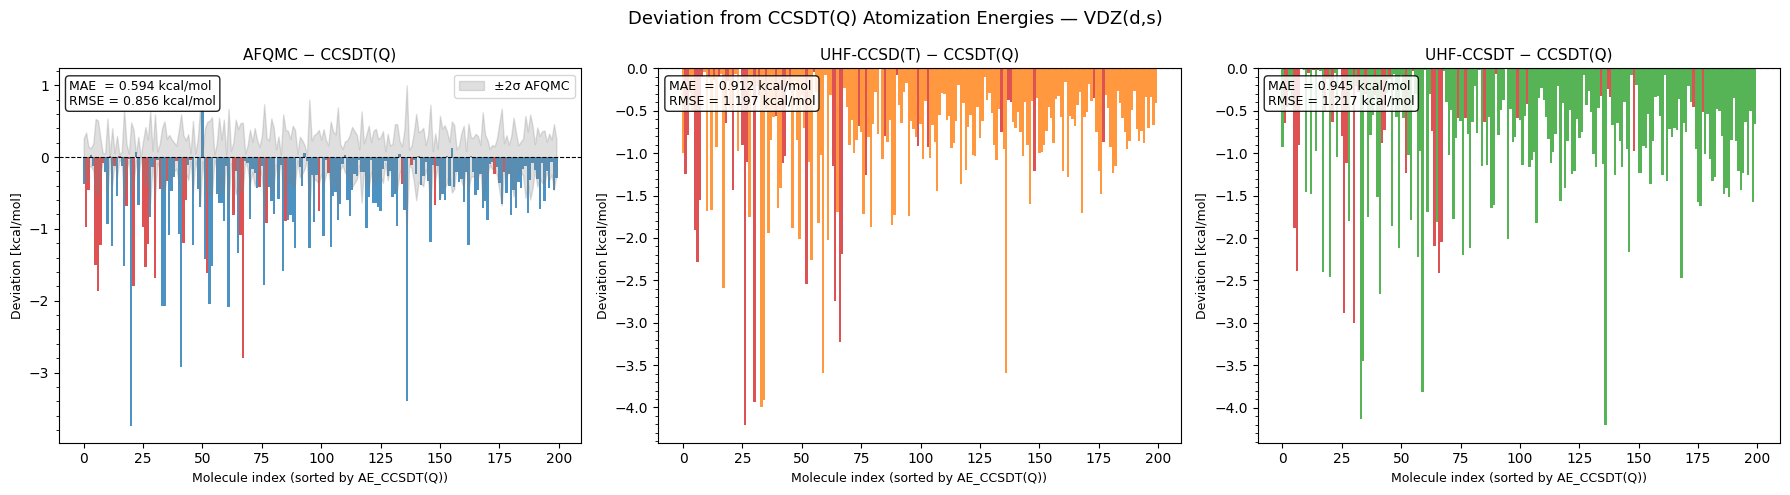

In [12]:
sort_idx = np.argsort(AE_CCSDTQ)
x = np.arange(len(mol_names))
is_open = (shells[sort_idx] == 'open')

methods_plot = [
    ('AFQMC',        dAFQMC,  '#1f77b4', AE_AFQMC_err),
    ('UHF-CCSD(T)',  dCCSD_T, '#ff7f0e', None),
    ('UHF-CCSDT',   dCCSDT,  '#2ca02c', None),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for ax, (label, delta, color, err) in zip(axes, methods_plot):
    y = delta[sort_idx]
    bar_colors = np.where(is_open, '#d62728', color)
    ax.bar(x, y, color=bar_colors, width=1.0, alpha=0.8)

    if err is not None:
        e = err[sort_idx] * 2   # 2-sigma
        ax.fill_between(x, -e, e, color='grey', alpha=0.25, label='±2σ AFQMC')

    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.set_title(f'{label} − CCSDT(Q)', fontsize=11)
    ax.set_xlabel('Molecule index (sorted by AE_CCSDT(Q))', fontsize=9)
    ax.set_ylabel('Deviation [kcal/mol]', fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

    mae  = np.abs(delta).mean()
    rmse = np.sqrt((delta**2).mean())
    ax.text(0.02, 0.97, f'MAE  = {mae:.3f} kcal/mol\nRMSE = {rmse:.3f} kcal/mol',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

from matplotlib.patches import Patch
legend_cs = Patch(facecolor='#1f77b4', label='closed-shell')
legend_os = Patch(facecolor='#d62728', label='open-shell')
axes[0].legend(handles=[legend_cs, legend_os], fontsize=9, loc='upper right')

if methods_plot[0][3] is not None:
    axes[0].legend(fontsize=9)

plt.suptitle('Deviation from CCSDT(Q) Atomization Energies — VDZ(d,s)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY, 'atomization_deviations_vdzsd.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8b. Error distribution histograms

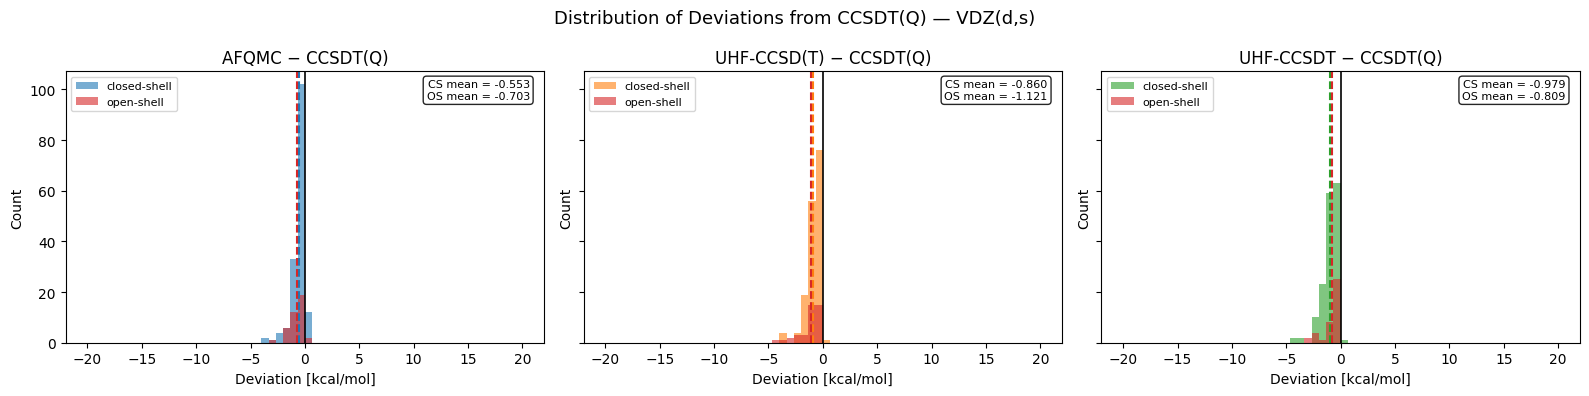

In [13]:
cs_mask = (shells == 'closed')
os_mask = (shells == 'open')

bins = np.linspace(-20, 20, 61)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (label, delta, color, _) in zip(axes, methods_plot):
    ax.hist(delta[cs_mask], bins=bins, color=color,    alpha=0.6, label='closed-shell')
    ax.hist(delta[os_mask], bins=bins, color='#d62728', alpha=0.6, label='open-shell')
    ax.axvline(0,                      color='k',      linewidth=1.2)
    ax.axvline(delta[cs_mask].mean(),   color=color,    linewidth=1.5, linestyle='--')
    ax.axvline(delta[os_mask].mean(),   color='#d62728', linewidth=1.5, linestyle='--')
    ax.set_title(f'{label} − CCSDT(Q)')
    ax.set_xlabel('Deviation [kcal/mol]')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.97,
            f'CS mean = {delta[cs_mask].mean():+.3f}\nOS mean = {delta[os_mask].mean():+.3f}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

plt.suptitle('Distribution of Deviations from CCSDT(Q) — VDZ(d,s)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SUMMARY, 'atomization_histograms_vdzsd.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8c. AFQMC vs CCSDT(Q) correlation plot

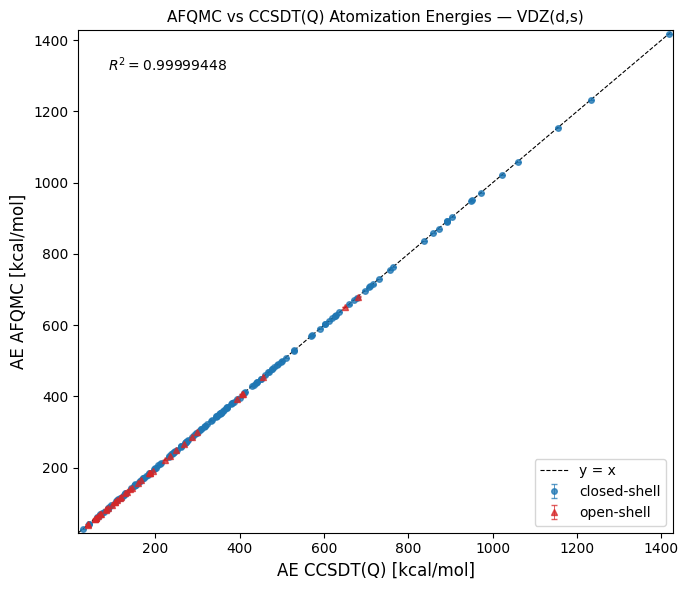

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))

for shell_label, mask, marker, color in [
    ('closed-shell', cs_mask, 'o', '#1f77b4'),
    ('open-shell',   os_mask, '^', '#d62728'),
]:
    ax.errorbar(
        AE_CCSDTQ[mask], AE_AFQMC[mask],
        yerr=2 * AE_AFQMC_err[mask],
        fmt=marker, ms=4, color=color, alpha=0.75,
        elinewidth=0.7, capsize=2, label=shell_label
    )

lim_lo = min(AE_CCSDTQ.min(), AE_AFQMC.min()) - 10
lim_hi = max(AE_CCSDTQ.max(), AE_AFQMC.max()) + 10
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', linewidth=0.8, label='y = x')
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)

r2 = np.corrcoef(AE_CCSDTQ, AE_AFQMC)[0, 1] ** 2
ax.text(0.05, 0.95, f'$R^2 = {r2:.8f}$', transform=ax.transAxes, va='top', fontsize=10)

ax.set_xlabel('AE CCSDT(Q) [kcal/mol]', fontsize=12)
ax.set_ylabel('AE AFQMC [kcal/mol]', fontsize=12)
ax.set_title('AFQMC vs CCSDT(Q) Atomization Energies — VDZ(d,s)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(SUMMARY, 'atomization_correlation_vdzsd.png'), dpi=150, bbox_inches='tight')
plt.show()

### 8d. Method comparison: MAE and RMSE bar chart

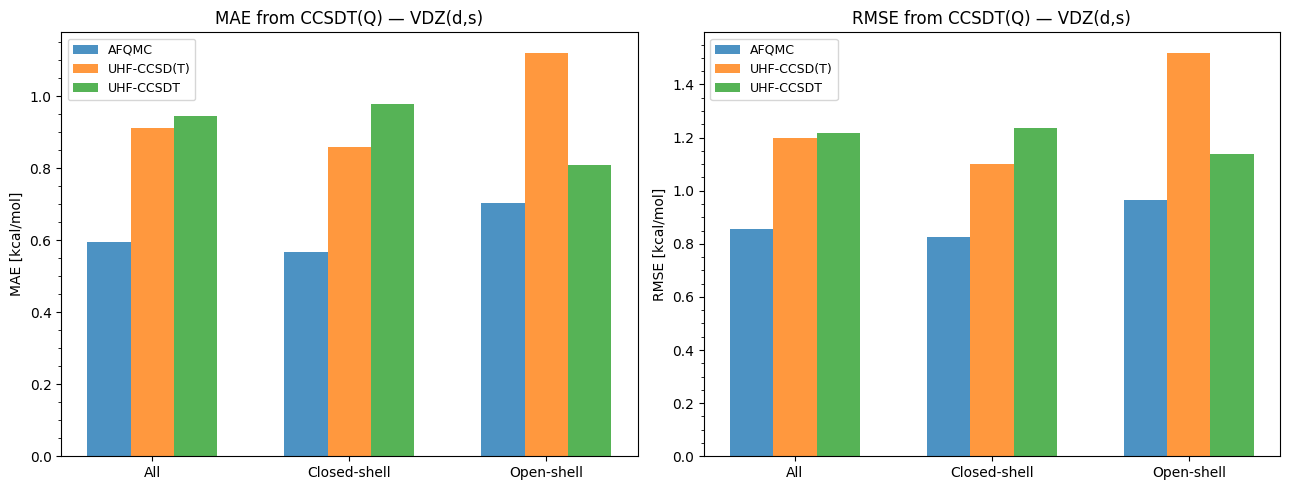

In [15]:
method_labels = ['AFQMC', 'UHF-CCSD(T)', 'UHF-CCSDT']
deltas = [dAFQMC, dCCSD_T, dCCSDT]
method_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

subset_labels = ['All', 'Closed-shell', 'Open-shell']
masks = [np.ones(len(mol_names), dtype=bool), cs_mask, os_mask]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, stat_label in enumerate(['MAE', 'RMSE']):
    ax = axes[ax_idx]
    n_subsets = len(subset_labels)
    n_methods = len(method_labels)
    w = 0.22
    x_base = np.arange(n_subsets)

    for j, (mlabel, delta, mcolor) in enumerate(zip(method_labels, deltas, method_colors)):
        vals = []
        for mask in masks:
            d = delta[mask]
            if stat_label == 'MAE':
                vals.append(np.abs(d).mean())
            else:
                vals.append(np.sqrt((d**2).mean()))
        offset = (j - 1) * w
        ax.bar(x_base + offset, vals, width=w, color=mcolor, alpha=0.8, label=mlabel)

    ax.set_xticks(x_base)
    ax.set_xticklabels(subset_labels)
    ax.set_ylabel(f'{stat_label} [kcal/mol]')
    ax.set_title(f'{stat_label} from CCSDT(Q) — VDZ(d,s)')
    ax.legend(fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig(os.path.join(SUMMARY, 'atomization_stats_vdzsd.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Export Results to CSV

In [ ]:
out_csv = os.path.join(SUMMARY, 'atomization_energies_vdzsd.csv')

header_csv = (','.join([
    'molecule', 'formula', '2S', 'shell',
    'AE_AFQMC_kcal', 'AE_AFQMC_err_kcal',
    'AE_UHF-CCSD(T)_kcal', 'AE_UHF-CCSDT_kcal', 'AE_CCSDT(Q)_kcal',
    'delta_AFQMC_kcal', 'delta_UHF-CCSD(T)_kcal', 'delta_UHF-CCSDT_kcal'
]))

with open(out_csv, 'w') as f:
    f.write(header_csv + '\n')
    for i in range(len(mol_names)):
        row = ','.join([
            mol_names[i], formulas[i], str(twos_arr[i]), shells[i],
            f"{AE_AFQMC[i]:.6f}",     f"{AE_AFQMC_err[i]:.6f}",
            f"{AE_CCSD_T[i]:.6f}",   f"{AE_CCSDT[i]:.6f}",   f"{AE_CCSDTQ[i]:.6f}",
            f"{dAFQMC[i]:.6f}",      f"{dCCSD_T[i]:.6f}",    f"{dCCSDT[i]:.6f}",
        ])
        f.write(row + '\n')

print(f"Saved {len(mol_names)} rows to {out_csv}")